# 04 — Employer Leaderboard & H-1B-to-Green-Card Pipeline

The single most actionable output for a student: a ranked list of employers worth targeting,
built from more than just "how many H-1Bs did they file." This combines volume, MBA-relevant
*mix*, certification reliability, whether filings represent real new openings (vs. renewals of
existing staff), and — for PERM — whether a filing is for someone already employed there vs. a
genuinely new hire. It also matches employers across LCA and PERM to see who actually carries
people from H-1B through to green card, not just who files a lot of H-1Bs.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_lca, load_perm, annual_wage  # noqa: E402
from mba_occupations import classify_mba_relevance  # noqa: E402
from employer_canonicalization import add_canonical_employer  # noqa: E402
from employer_matching import match_employers  # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
FIG_DIR = Path.cwd().parent / "outputs" / "figures"

In [2]:
lca = load_lca()
perm = load_perm()

lca["MBA_TIER"] = classify_mba_relevance(lca["SOC_CODE"], lca["SOC_TITLE"])
perm["MBA_TIER"] = classify_mba_relevance(perm["PWD_SOC_CODE"], perm["PWD_SOC_TITLE"])

lca = add_canonical_employer(lca, "EMPLOYER_NAME", "EMPLOYER_CANONICAL")
perm = add_canonical_employer(perm, "EMP_BUSINESS_NAME", "EMPLOYER_CANONICAL")

lca["ANNUAL_WAGE_FROM"] = annual_wage(lca["WAGE_RATE_OF_PAY_FROM"], lca["WAGE_UNIT_OF_PAY"])
lca["IS_NEW_POSITION"] = lca["NEW_EMPLOYMENT"].fillna(0) > 0

lca_mba = lca[lca["MBA_TIER"] != "excluded"].copy()
perm_mba = perm[perm["MBA_TIER"] != "excluded"].copy()

## What share of "MBA-relevant" LCA filings are actually new positions?

`NEW_EMPLOYMENT` counts new-position slots on a filing; `CONTINUED_EMPLOYMENT`/
`CHANGE_EMPLOYER` cover extensions and transfers for people already employed. A filing with
`NEW_EMPLOYMENT > 0` is the closer proxy to "there's a real open seat here" — this is a
stronger signal than excluding `Withdrawn` status, which the original data-quality question
was really asking about.

In [3]:
new_position_share = lca_mba["IS_NEW_POSITION"].mean()
print(f"Share of MBA-relevant LCA filings that include a new position: {new_position_share:.1%}")

Share of MBA-relevant LCA filings that include a new position: 38.5%


## PERM: existing employee vs. genuinely new hire

`OTHER_REQ_IS_FW_CURRENTLY_WRK` = Y means the foreign worker is already working for that
employer in that job at filing time — i.e. this PERM case is a green-card *conversion*, not a
green-card offer to an outside candidate. Only the N share represents "will sponsor a green
card for someone not already there."

In [4]:
perm_currently_working = perm_mba["OTHER_REQ_IS_FW_CURRENTLY_WRK"].value_counts(normalize=True, dropna=False)
print(perm_currently_working)
print(f"\nShare of MBA-relevant PERM filings for an external/new hire: {perm_currently_working.get('N', 0):.1%}")

OTHER_REQ_IS_FW_CURRENTLY_WRK
Y    0.858435
N    0.141565
Name: proportion, dtype: float64

Share of MBA-relevant PERM filings for an external/new hire: 14.2%


## Employer scorecard

One row per employer: MBA-relevant volume, MBA-relevant mix (share of that employer's *total*
filings, not just raw count — a small employer that's 100% business-track roles is a better
lead than a huge filer where MBA-relevant roles are a rounding error), certification rate, new
vs. renewal share, and DOL's own risk flags.

In [5]:
def employer_scorecard_lca(df, min_filings=10):
    g = df.groupby("EMPLOYER_CANONICAL").agg(
        total_filings=("MBA_TIER", "count"),
        mba_relevant_filings=("MBA_TIER", lambda s: (s != "excluded").sum()),
        certified=("CASE_STATUS", lambda s: (s != "Denied").mean()),
        new_position_share=("IS_NEW_POSITION", "mean"),
        median_annual_wage=("ANNUAL_WAGE_FROM", "median"),
        any_willful_violator=("WILLFUL_VIOLATOR", lambda s: (s == "Y").any()),
        any_h1b_dependent=("H_1B_DEPENDENT", lambda s: (s == "Y").any()),
    )
    g["mba_share"] = g["mba_relevant_filings"] / g["total_filings"]
    return g[g["mba_relevant_filings"] >= min_filings].sort_values(
        ["mba_share", "mba_relevant_filings"], ascending=False
    )


lca_scorecard = employer_scorecard_lca(lca)
lca_scorecard.head(25)

,total_filings,mba_relevant_filings,certified,new_position_share,median_annual_wage,any_willful_violator,any_h1b_dependent,mba_share
EMPLOYER_CANONICAL,,,,,,,,
"MANHATTAN ASSOCIATES, INC.",197,197,1.000000,0.197970,132500.0,False,False,1.0
"SCOTIA CAPITAL (USA), INC.",101,101,0.970297,0.485149,145000.0,False,False,1.0
"Standish Management US, LLC",92,92,1.000000,0.423913,91250.0,False,False,1.0
Ernst & Young LLP (EY GUAM),67,67,1.000000,0.522388,46000.0,False,False,1.0
The Siegfried Group LLP,59,59,1.000000,0.491525,140000.0,False,False,1.0
"Houlihan Lokey Financial Advisors, Inc.",57,57,1.000000,0.578947,147000.0,False,False,1.0
"The Smile Mission South Miami, PLLC",39,39,1.000000,0.897436,73500.0,False,False,1.0
Macquarie America Holdings Inc.,35,35,1.000000,0.428571,140000.0,False,False,1.0
"Alvarez & Marsal Consumer and Retail Group, LLC",34,34,1.000000,0.705882,175000.0,False,False,1.0


In [6]:
def employer_scorecard_perm(df, min_filings=5):
    g = df.groupby("EMPLOYER_CANONICAL").agg(
        total_filings=("MBA_TIER", "count"),
        mba_relevant_filings=("MBA_TIER", lambda s: (s != "excluded").sum()),
        certified=("CASE_STATUS", lambda s: (s != "Denied").mean()),
        external_hire_share=("OTHER_REQ_IS_FW_CURRENTLY_WRK", lambda s: (s == "N").mean()),
        median_company_payroll=("EMP_NUM_PAYROLL", "median"),
    )
    g["mba_share"] = g["mba_relevant_filings"] / g["total_filings"]
    return g[g["mba_relevant_filings"] >= min_filings].sort_values(
        ["mba_share", "mba_relevant_filings"], ascending=False
    )


perm_scorecard = employer_scorecard_perm(perm)
perm_scorecard.head(25)

,total_filings,mba_relevant_filings,certified,external_hire_share,median_company_payroll,mba_share
EMPLOYER_CANONICAL,,,,,,
"BDO USA, P.C. (FKA BDO USA, LLP)",47,47,1.000000,0.000000,282.0,1.0
EVERCORE PARTNERS SERVICES EAST LLC,34,34,1.000000,0.029412,1285.0,1.0
SQUAREPOINT SERVICES US LLC,26,26,1.000000,0.038462,214.0,1.0
"BDO USA, P.C.",21,21,1.000000,0.047619,289.0,1.0
Macias Gini & O'Connell LLP,17,17,1.000000,0.000000,54.0,1.0
The Siegfried Group LLP,15,15,1.000000,0.066667,226.0,1.0
Spike Inc.,14,14,1.000000,0.357143,32.0,1.0
"Bayview Asset Management, LLC",13,13,0.923077,0.000000,214.0,1.0
Funaro & Co. PC,13,13,0.846154,0.000000,100.0,1.0


## Company size (PERM only): does bigger/older mean more reliable sponsorship?

`EMP_NUM_PAYROLL` (total employees) and `EMP_YEAR_COMMENCED` (founding year) are only on the
PERM side. Useful context for risk tolerance: a large, long-established filer is a more
predictable sponsor than a small/young one, even if the small one's per-filing certification
rate looks fine on a handful of cases.

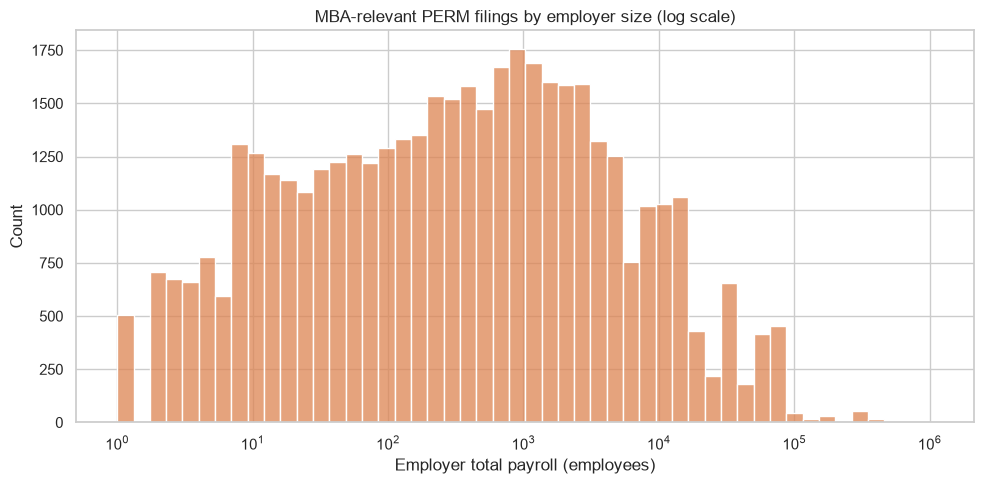

In [7]:
perm_mba_valid = perm_mba[(perm_mba["EMP_NUM_PAYROLL"] > 0) & (perm_mba["EMP_NUM_PAYROLL"] < 2_000_000)]
fig, ax = plt.subplots()
sns.histplot(perm_mba_valid["EMP_NUM_PAYROLL"], bins=50, log_scale=True, ax=ax, color="#DD8452")
ax.set_title("MBA-relevant PERM filings by employer size (log scale)")
ax.set_xlabel("Employer total payroll (employees)")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_employer_size_distribution.png", dpi=150)
plt.show()

## The pipeline view: who sponsors both H-1B and green cards for business roles?

Employers present in both `lca_mba` and `perm_mba` (matched on a cleaned/suffix-stripped
employer name, same heuristic as the canonicalization step — see `src/employer_matching.py`
for the caveats) represent the full pathway a student actually wants: work visa now, green
card path later.

In [8]:
pipeline = match_employers(lca_mba, perm_mba)
both = pipeline[pipeline["sponsors_both"]].sort_values(
    ["lca_filings", "perm_filings"], ascending=False
)
print(f"Employers sponsoring MBA-relevant roles in both LCA and PERM: {len(both):,}")
both[["lca_canonical_name", "lca_filings", "perm_filings"]].head(30)

Employers sponsoring MBA-relevant roles in both LCA and PERM: 8,885


,lca_canonical_name,lca_filings,perm_filings
2808,Amazon.com Services LLC,10203,30
16729,Ernst & Young U.S. LLP,9253,575
13792,Deloitte Consulting LLP,2219,349
31631,Microsoft Corporation,2123,780
26238,JPMorgan Chase & Co.,2109,373
3785,Apple Inc.,1994,133
20543,GOLDMAN SACHS & CO. LLC,1784,370
31362,"Meta Platforms, Inc",1706,36
13796,Deloitte Tax LLP,1490,152
13791,Deloitte & Touche LLP,1486,31


In [9]:
lca_only = pipeline[(pipeline["lca_filings"] > 0) & (pipeline["perm_filings"] == 0)]
print(f"MBA-relevant LCA filers with no matched PERM filings: {len(lca_only):,} "
      f"(out of {(pipeline['lca_filings'] > 0).sum():,} total LCA filers)")

MBA-relevant LCA filers with no matched PERM filings: 36,489 (out of 45,374 total LCA filers)


A caveat worth repeating here: "no matched PERM filings" can mean the employer genuinely
doesn't sponsor green cards for these roles, *or* it can mean the name-matching missed a
legitimate match (small/generic employer names are the likeliest misses). Treat `lca_only` as
"worth double-checking," not "confirmed no PERM path."

## Save dashboard-ready aggregates

In [10]:
lca_scorecard.reset_index().to_csv(PROCESSED_DIR / "lca_employer_scorecard.csv", index=False)
perm_scorecard.reset_index().to_csv(PROCESSED_DIR / "perm_employer_scorecard.csv", index=False)
pipeline.to_csv(PROCESSED_DIR / "employer_lca_perm_pipeline.csv", index=False)

print("Saved employer leaderboard + pipeline aggregates to", PROCESSED_DIR)

Saved employer leaderboard + pipeline aggregates to /Users/jaime/Local Documents/GitHub/h1b_analysis/data/processed


## Notes

- `any_willful_violator`/`any_h1b_dependent` are DOL's own published flags — presented as
  factual context (an employer could have resolved a past violation, and H-1B-dependent status
  just triggers extra attestation requirements, it isn't inherently bad), not a blacklist.
- PERM's external-hire share is a *company-wide* PERM statistic, not tier-specific for small
  employers with few filings — read it directionally for employers near the `min_filings`
  threshold.